# Network Intrusion Detection
### Binary Classification (Random Forest) + Multi-Class Classification (PyTorch DNN)

**Dataset:** Network traffic logs - 80 features, 7 label classes  
**Task 1:** Benign vs. Attack - Random Forest Classifier  
**Task 2:** All 7 traffic types - Linear Deep Neural Network (PyTorch)

---
## Section 0 — Imports & Reproducibility

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Set all seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All libraries imported.')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

All libraries imported.
PyTorch version : 2.5.1
Device          : CPU


---
## Section 1 - Data Loading

In [2]:
folder_path = r'C:\ProjectML\Training_data'
file_names  = ['m_1.csv', 'm_2.csv', 'm_3.csv']

# low_memory=False prevents mixed-dtype warnings on large files
df_list = [
    pd.read_csv(os.path.join(folder_path, f), low_memory=False)
    for f in file_names
]
df = pd.concat(df_list, ignore_index=True)

print(f'Rows after concat : {len(df):,}')
print(f'Columns           : {len(df.columns)}')
print(f'\nRaw label distribution:')
print(df['Label'].value_counts())

Rows after concat : 3,145,725
Columns           : 80

Raw label distribution:
Label
Benign                      1475231
DDOS attack-HOIC             686012
DoS attacks-Hulk             461912
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DDOS attack-LOIC-UDP           1730
Label                             1
Name: count, dtype: int64


---
## Section 2 - Preprocessing

In [ ]:

df = df[df['Label'] != 'Label'].copy()
print(f'Rows after removing duplicate headers : {len(df):,}')

Rows after removing duplicate headers : 3,145,724


In [ ]:

df.drop(columns=['Timestamp'], errors='ignore', inplace=True)

In [ ]:

feature_cols = [c for c in df.columns if c != 'Label']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
print('All feature columns cast to numeric.')

All feature columns cast to numeric.


In [ ]:

df[feature_cols] = df[feature_cols].replace(-1, np.nan)
print('Sentinel -1 values replaced with NaN.')

Sentinel -1 values replaced with NaN.


In [ ]:

df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f'Rows dropped (NaN / Inf / sentinel) : {before - len(df):,}')
print(f'Rows remaining                      : {len(df):,}')

Rows dropped (NaN / Inf / sentinel) : 1,311,770
Rows remaining                      : 1,833,954


In [ ]:

X_raw = df[feature_cols]
zero_var_cols = X_raw.columns[X_raw.std() == 0].tolist()
print(f'Zero-variance columns dropped : {zero_var_cols}')

X_raw = X_raw.drop(columns=zero_var_cols)
y_raw = df['Label']

print(f'Final feature count           : {X_raw.shape[1]}')
print(f'Final label distribution:')
print(y_raw.value_counts())

Zero-variance columns dropped : ['Protocol', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Final feature count           : 67
Final label distribution:
Label
Benign                      1123828
FTP-BruteForce               193354
SSH-Bruteforce               187584
DDOS attack-HOIC             163750
DoS attacks-SlowHTTPTest     139890
DoS attacks-Hulk              25548
Name: count, dtype: int64


---
## Section 3 - Task 1: Binary Classification (Random Forest)

In [9]:
# Binary label encoding: 0 = Benign, 1 = Attack
y_binary = y_raw.apply(lambda lbl: 0 if lbl == 'Benign' else 1)
print('Binary label distribution:')
print(y_binary.value_counts().rename({0: 'Benign (0)', 1: 'Attack (1)'}))

# Train / test split BEFORE scaling to prevent data leakage.
# Data leakage = scaler learning test set statistics, inflating eval metrics.
X_train_raw_b, X_test_raw_b, y_train_bin, y_test_bin = train_test_split(
    X_raw, y_binary,
    test_size=0.2, random_state=SEED, stratify=y_binary
)
print(f'\nTrain size : {len(X_train_raw_b):,}  |  Test size : {len(X_test_raw_b):,}')

Binary label distribution:
Label
Benign (0)    1123828
Attack (1)     710126
Name: count, dtype: int64

Train size : 1,467,163  |  Test size : 366,791


In [10]:
# Feature scaling — fit on train only, transform both sets
# fit_transform on train: learns mean and std from training data only
# transform on test: applies those same statistics without re-fitting
scaler_b = StandardScaler()
X_train_bin = scaler_b.fit_transform(X_train_raw_b)
X_test_bin  = scaler_b.transform(X_test_raw_b)
print('Scaling complete (no data leakage).')

Scaling complete (no data leakage).


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_bin, y_train_bin)
print('Random Forest training complete.')

Random Forest training complete.


In [12]:
y_pred_bin = rf_model.predict(X_test_bin)

print('Random Forest — Binary Classification Report')
print('=' * 55)
print(classification_report(y_test_bin, y_pred_bin, target_names=['Benign', 'Attack']))

Random Forest — Binary Classification Report
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    224766
      Attack       1.00      1.00      1.00    142025

    accuracy                           1.00    366791
   macro avg       1.00      1.00      1.00    366791
weighted avg       1.00      1.00      1.00    366791



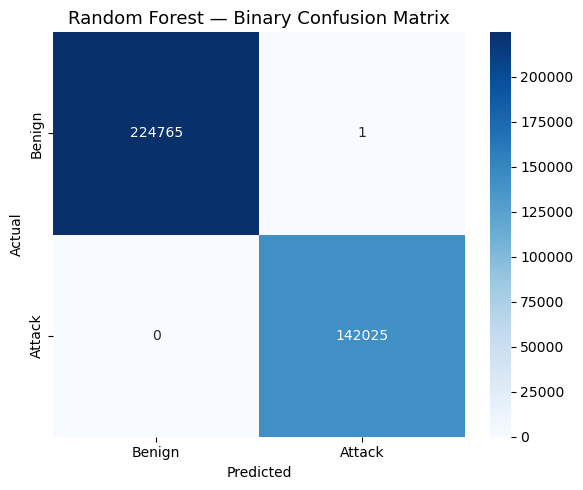

Saved: cm_binary_rf.png


In [13]:
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bin, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Attack'],
    yticklabels=['Benign', 'Attack']
)
plt.title('Random Forest — Binary Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_binary_rf.png', dpi=150)
plt.show()
print('Saved: cm_binary_rf.png')

---
## Section 4 - Task 2: Multi-Class Classification (PyTorch DNN)

In [14]:
# Encode 7-class labels to integers
encoder = LabelEncoder()
y_multi = encoder.fit_transform(y_raw)

print('Encoded classes:')
for idx, cls in enumerate(encoder.classes_):
    print(f'  {idx} : {cls}')

# Train / test split BEFORE scaling
X_train_raw_m, X_test_raw_m, y_train_m, y_test_m = train_test_split(
    X_raw, y_multi,
    test_size=0.2, random_state=SEED, stratify=y_multi
)
print(f'\nTrain size : {len(X_train_raw_m):,}  |  Test size : {len(X_test_raw_m):,}')

Encoded classes:
  0 : Benign
  1 : DDOS attack-HOIC
  2 : DoS attacks-Hulk
  3 : DoS attacks-SlowHTTPTest
  4 : FTP-BruteForce
  5 : SSH-Bruteforce

Train size : 1,467,163  |  Test size : 366,791


In [15]:
# Feature scaling for multi-class task (fresh scaler, same logic)
scaler_m = StandardScaler()
X_train_sc = scaler_m.fit_transform(X_train_raw_m)
X_test_sc  = scaler_m.transform(X_test_raw_m)
print('Scaling complete.')

Scaling complete.


In [16]:
# Build DataLoaders with mini-batches
# Mini-batching prevents out-of-memory errors on large datasets and gives
# the optimizer more frequent gradient updates than processing all data at once.
BATCH_SIZE = 512

train_dataset = TensorDataset(
    torch.FloatTensor(X_train_sc),
    torch.LongTensor(y_train_m)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_sc),
    torch.LongTensor(y_test_m)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size       : {BATCH_SIZE}')
print(f'Training batches : {len(train_loader)}')

Batch size       : 512
Training batches : 2866


In [17]:
class IntrusionDNN(nn.Module):
    """
    3-layer fully-connected network for 7-class intrusion detection.

    Architecture : input_dim -> 128 -> 64 -> num_classes
    Activations  : ReLU after each hidden layer
    Regularisation: Dropout(p=0.3) after the first hidden layer

    Dropout randomly zeros 30% of activations during training, forcing the
    network to learn redundant, distributed representations rather than
    memorising training samples (overfitting).

    Output layer returns raw logits. CrossEntropyLoss applies softmax
    internally, which is numerically more stable than doing it manually.
    """
    def __init__(self, input_dim: int, num_classes: int):
        super(IntrusionDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),           # required regularisation layer
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)   # raw logits output
        )

    def forward(self, x):
        return self.network(x)

print('DNN architecture defined.')

DNN architecture defined.


In [18]:
# Hyperparameters
INPUT_DIM     = X_train_sc.shape[1]
NUM_CLASSES   = len(encoder.classes_)   # 7
LEARNING_RATE = 0.001
EPOCHS        = 50
DROPOUT_RATE  = 0.3
HIDDEN_1      = 128
HIDDEN_2      = 64
# BATCH_SIZE already defined above as 512

print('--- DNN Hyperparameters ---')
print(f'  input_dim     : {INPUT_DIM}')
print(f'  hidden_layer_1: {HIDDEN_1}')
print(f'  hidden_layer_2: {HIDDEN_2}')
print(f'  num_classes   : {NUM_CLASSES}')
print(f'  dropout_rate  : {DROPOUT_RATE}')
print(f'  learning_rate : {LEARNING_RATE}')
print(f'  epochs        : {EPOCHS}')
print(f'  batch_size    : {BATCH_SIZE}')

--- DNN Hyperparameters ---
  input_dim     : 67
  hidden_layer_1: 128
  hidden_layer_2: 64
  num_classes   : 6
  dropout_rate  : 0.3
  learning_rate : 0.001
  epochs        : 50
  batch_size    : 512


In [19]:
# Class weights to handle extreme imbalance
# DDOS attack-LOIC-UDP is only 0.05% of the data. Without weighting the loss
# barely penalises the model for ignoring it entirely.
# class_weight='balanced' scales each class inversely to its frequency.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_m),
    y=y_train_m
)
class_weights_tensor = torch.FloatTensor(class_weights)

print('Class weights applied to loss function:')
for cls, w in zip(encoder.classes_, class_weights):
    print(f'  {cls:<38} : {w:.4f}')

Class weights applied to loss function:
  Benign                                 : 0.2720
  DDOS attack-HOIC                       : 1.8666
  DoS attacks-Hulk                       : 11.9638
  DoS attacks-SlowHTTPTest               : 2.1850
  FTP-BruteForce                         : 1.5808
  SSH-Bruteforce                         : 1.6295


In [20]:
model     = IntrusionDNN(INPUT_DIM, NUM_CLASSES)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

IntrusionDNN(
  (network): Sequential(
    (0): Linear(in_features=67, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [21]:
# Training loop with train and validation loss tracking
# Tracking both allows us to detect overfitting:
# if val loss rises while train loss keeps falling, the model is memorising.
train_losses = []
val_losses   = []

print(f'Training DNN for {EPOCHS} epochs...')
print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}')
print('-' * 34)

for epoch in range(1, EPOCHS + 1):

    # Training phase — dropout ACTIVE
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(X_batch)
    avg_train_loss = running_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # Validation phase — dropout DISABLED
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs   = model(X_batch)
            loss      = criterion(outputs, y_batch)
            val_loss += loss.item() * len(X_batch)
    avg_val_loss = val_loss / len(test_dataset)
    val_losses.append(avg_val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6}  {avg_train_loss:>12.4f}  {avg_val_loss:>10.4f}')

print('\nTraining complete.')

Training DNN for 50 epochs...
 Epoch    Train Loss    Val Loss
----------------------------------
     1        0.2025      0.1809
     5        0.1792      0.1778
    10        0.1787      0.1774
    15        0.1761      0.1753
    20        0.1746      0.1730
    25        0.1744      0.1738
    30        0.1746      0.1761
    35        0.1746      0.1834
    40        0.1746      0.1829
    45        0.1758      0.1847
    50        0.1760      0.1887

Training complete.


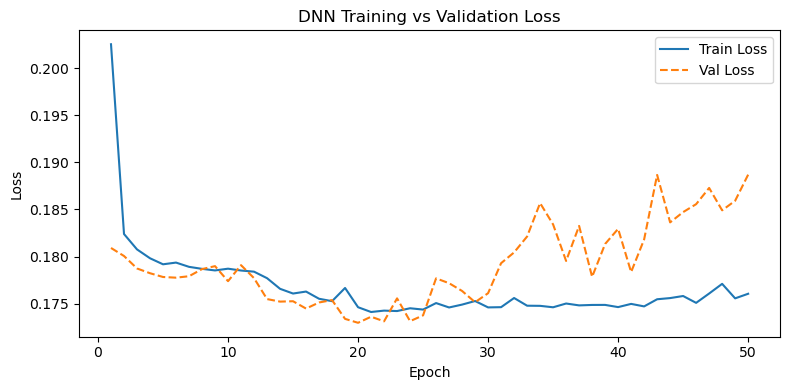

Saved: dnn_loss_curve.png


In [22]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses,   label='Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DNN Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('dnn_loss_curve.png', dpi=150)
plt.show()
print('Saved: dnn_loss_curve.png')

In [23]:
# Final evaluation — collect predictions batch by batch
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

print('DNN — Multi-Class Classification Report')
print('=' * 65)
print(classification_report(all_labels, all_preds, target_names=encoder.classes_))

DNN — Multi-Class Classification Report
                          precision    recall  f1-score   support

                  Benign       1.00      1.00      1.00    224766
        DDOS attack-HOIC       1.00      1.00      1.00     32750
        DoS attacks-Hulk       1.00      1.00      1.00      5109
DoS attacks-SlowHTTPTest       0.53      0.92      0.67     27978
          FTP-BruteForce       0.87      0.41      0.56     38671
          SSH-Bruteforce       1.00      1.00      1.00     37517

                accuracy                           0.93    366791
               macro avg       0.90      0.89      0.87    366791
            weighted avg       0.95      0.93      0.93    366791



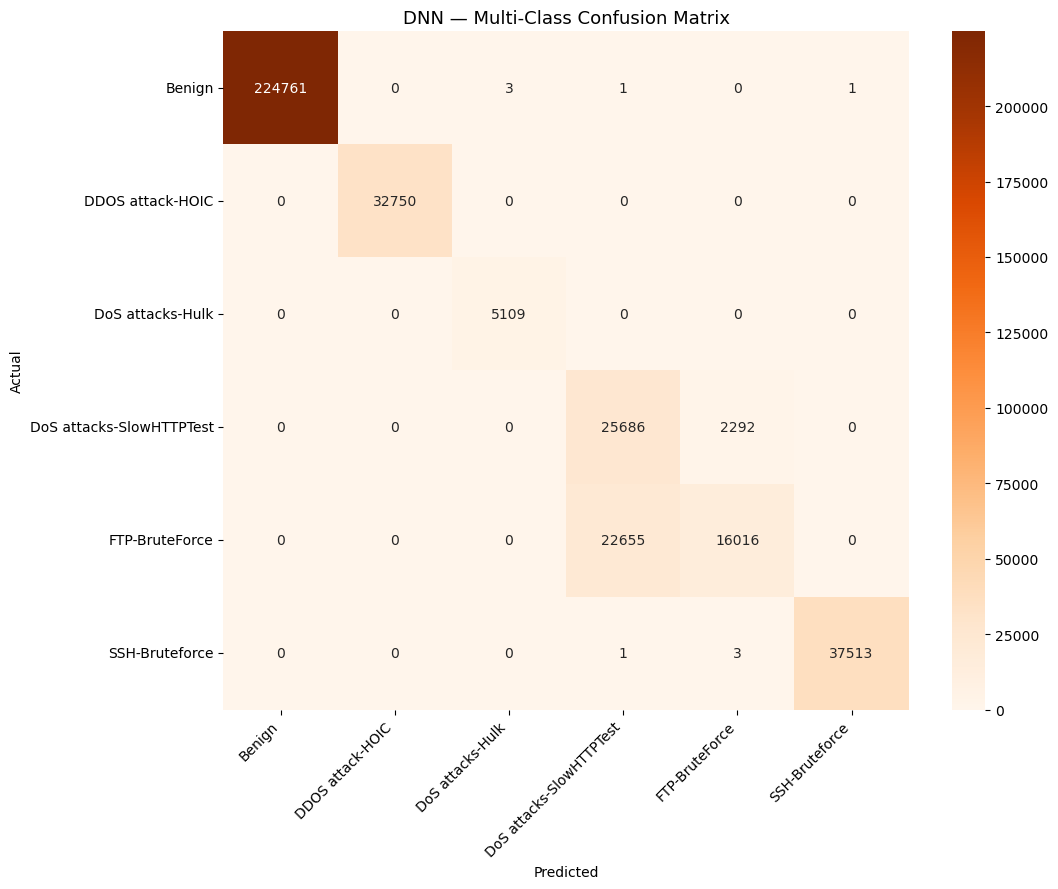

Saved: cm_multiclass_dnn.png


In [24]:
cm_multi = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_multi, annot=True, fmt='d', cmap='Oranges',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('DNN — Multi-Class Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cm_multiclass_dnn.png', dpi=150)
plt.show()
print('Saved: cm_multiclass_dnn.png')

In [25]:
print(encoder.classes_)
print(pd.Series(y_raw).value_counts())

['Benign' 'DDOS attack-HOIC' 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest'
 'FTP-BruteForce' 'SSH-Bruteforce']
Label
Benign                      1123828
FTP-BruteForce               193354
SSH-Bruteforce               187584
DDOS attack-HOIC             163750
DoS attacks-SlowHTTPTest     139890
DoS attacks-Hulk              25548
Name: count, dtype: int64


In [27]:
# Audit: check class survival after preprocessing
print("Classes the encoder learned (survived preprocessing):")
print(encoder.classes_)

print(f"\nTotal classes in encoder: {len(encoder.classes_)}")

print("\nAfter preprocessing label distribution:")
print(y_raw.value_counts())

print("\nConclusion:")
print("DDOS attack-LOIC-UDP is absent from both the encoder and the")
print("label distribution, confirming it was fully removed during preprocessing.")
print("Original dataset had 7 classes. Only 6 survived.")

Classes the encoder learned (survived preprocessing):
['Benign' 'DDOS attack-HOIC' 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest'
 'FTP-BruteForce' 'SSH-Bruteforce']

Total classes in encoder: 6

After preprocessing label distribution:
Label
Benign                      1123828
FTP-BruteForce               193354
SSH-Bruteforce               187584
DDOS attack-HOIC             163750
DoS attacks-SlowHTTPTest     139890
DoS attacks-Hulk              25548
Name: count, dtype: int64

Conclusion:
DDOS attack-LOIC-UDP is absent from both the encoder and the
label distribution, confirming it was fully removed during preprocessing.
Original dataset had 7 classes. Only 6 survived.
